In [2]:
import numpy as np
import matplotlib.pyplot as plt

R = 1.0
lambda_charge = 1.0
k = 1.0

z = 1.0

n_grid = 50
n_ring = 100

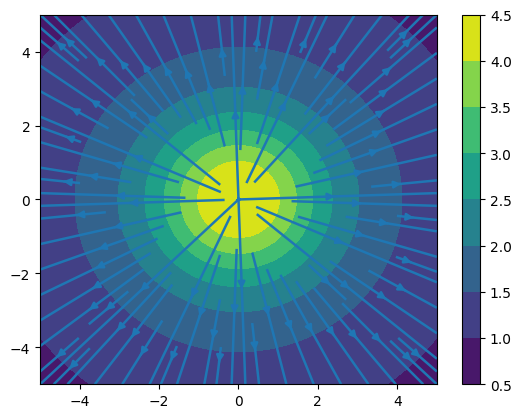

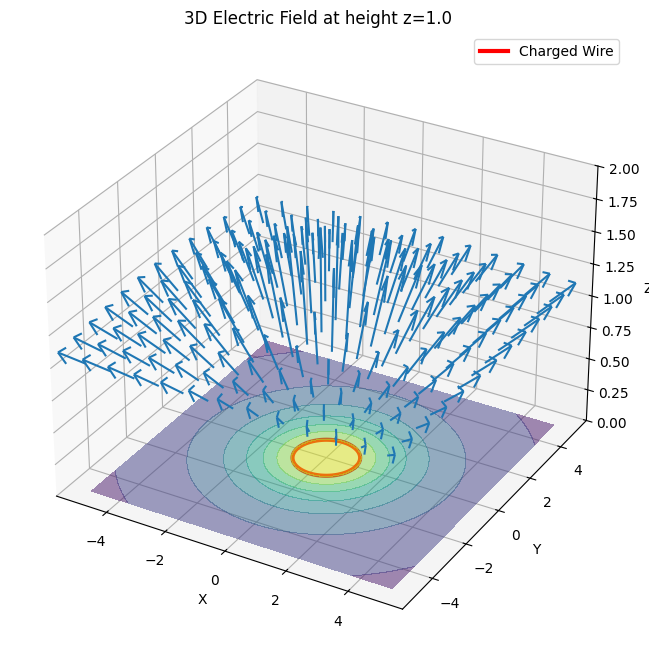

In [4]:
x_grid = np.linspace(-5.0, 5.0, n_grid)
y_grid = np.linspace(-5.0, 5.0, n_grid)
grid = np.meshgrid(x_grid, y_grid)

theta_prime_values = np.linspace(0.0, 2.0 * np.pi, n_ring, endpoint=False)
d_theta = 2.0 * np.pi / n_ring

V = np.zeros_like(grid[0])
Ex = np.zeros_like(grid[0])
Ey = np.zeros_like(grid[0])
Ez = np.zeros_like(grid[0])

for theta_prime in theta_prime_values:
    distance = np.sqrt((grid[0] - R * np.cos(theta_prime))**2 + (grid[1] - R * np.sin(theta_prime))**2 + z**2)

    dV = k * lambda_charge * R * d_theta / distance
    V += dV

    dEx = k * lambda_charge * R * d_theta * (grid[0] - R * np.cos(theta_prime)) / distance**3
    dEy = k * lambda_charge * R * d_theta * (grid[1] - R * np.sin(theta_prime)) / distance**3
    dEz = k * lambda_charge * R * d_theta * z / distance**3

    Ex += dEx
    Ey += dEy
    Ez += dEz

cs = plt.contourf(grid[0], grid[1], V)
cbar = plt.colorbar(cs)

plt.streamplot(grid[0], grid[1], Ex, Ey, color='tab:blue', linewidth=1.8)

plt.show()


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # Turns on 3D mode

# 1. Create a Z-coordinate matrix filled with your constant 'z' height
Z_grid = np.full_like(grid[0], z)

# 2. Slice the arrays to skip points (avoids the "hairball" look)
# This takes every 4th point in both the rows and columns
step = 4
x_s = grid[0][::step, ::step]
y_s = grid[1][::step, ::step]
z_s = Z_grid[::step, ::step]
ex_s = Ex[::step, ::step]
ey_s = Ey[::step, ::step]
ez_s = Ez[::step, ::step]

# 3. Plot the 3D electric field vectors
# 'normalize=True' makes all arrows the same length so it's easier to see the direction
ax.quiver(x_s, y_s, z_s, ex_s, ey_s, ez_s, length=0.8, normalize=True, color='tab:blue')

# Optional but highly recommended: Draw the physical wire at z=0 for visual context!
theta_plot = np.linspace(0, 2 * np.pi, 100)
ax.plot(R * np.cos(theta_plot), R * np.sin(theta_plot), 0, color='red', linewidth=3, label='Charged Wire')

# You can even project your potential contour onto the "floor" of the 3D plot (at z=0)
ax.contourf(grid[0], grid[1], V, zdir='z', offset=0, cmap='viridis', alpha=0.5)

# Formatting
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(0, z + 1) # Sets the vertical axis limits
ax.set_title(f'3D Electric Field at height z={z}')
ax.legend()

plt.show()
